In [1]:
import pandas as pd
import numpy as np
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import seaborn as sns

This notebook filters, summarizes, and interprets ShatterSeek results (chromothripsis events)

In [2]:
results = pd.read_csv('../results/shatterseek_master_results.csv')
print(f"Loaded {len(results)} rows from {results['sample_id'].nunique()} samples")
print(results['start'].nunique())
print(results.sort_values('clusterSize_including_TRA', ascending=False).head(10))

Loaded 5244 rows from 228 samples
3591
     chrom       start          end  number_DEL  number_DUP  number_h2hINV  \
2101     9  75908341.0  133462811.0          89         100             93   
655     12   4648289.0  128897360.0          72          73             72   
2307     8  18855482.0  141064897.0          49          32             48   
3066     8  18855482.0  141063166.0          45          39             47   
2719     6  37486451.0  164261311.0          39          56             43   
3037     2    138276.0  240727007.0          22          19             18   
811      7  63054588.0  159064012.0          55          65             57   
1523     6   1694273.0  170564515.0          12           8             12   
3038     3    648884.0  178586629.0          17          21             17   
3266     1  32816679.0   67552893.0          44          64             41   

      number_t2tINV  number_TRA  clusterSize_including_TRA  number_SVs_sample  \
2101            107  

In [3]:
# Apply per-sample FDR (Benjamini-Hochberg) correction to p-values to be used in filtering 
pval_cols = ['pval_fragment_joins', 'chr_breakpoint_enrichment', 'pval_exp_cluster'] # may have to use pval_exp_chr and/or inter_pval_fragment_joins

def apply_per_sample_fdr(data, pval_columns):
    for col in pval_columns:
        fdr_col = f"{col}_fdr"
        data[fdr_col] = pd.NA
        
        for sample_id in data['sample_id'].unique():
            mask = data['sample_id'] == sample_id
            sample_pvals = data.loc[mask, col].dropna()
            
            if len(sample_pvals) > 0:
                fdr_corrected = false_discovery_control(sample_pvals, method='bh')
                data.loc[mask & data[col].notna(), fdr_col] = fdr_corrected
    
    return data

results_fdr = apply_per_sample_fdr(results.copy(), pval_cols)

print("\n=== FDR Correction Summary ===")
for col in pval_cols:
    fdr_col = f"{col}_fdr"
    
    # significant events before vs after
    if col == 'pval_fragment_joins': # for the fragment joins test, chromothripsis events will be NOT significant (P > 0.05)
        orig_not_sig = (results[col] > 0.05).sum()
        fdr_not_sig = (results_fdr[fdr_col] > 0.05).sum()
        total_tests = results[col].notna().sum()
        print(f"{col}:")
        print(f"  Total tests across all samples: {total_tests}, Original not sig: {orig_not_sig}, FDR not sig: {fdr_not_sig}")
    else:
        orig_sig = (results[col] < 0.01).sum()
        fdr_sig = (results_fdr[fdr_col] < 0.01).sum()
        total_tests = results[col].notna().sum()
        print(f"{col}:")
        print(f"  Total tests across all samples: {total_tests}, Original sig: {orig_sig}, FDR sig: {fdr_sig}")

results_fdr


=== FDR Correction Summary ===
pval_fragment_joins:
  Total tests across all samples: 3797, Original not sig: 3624, FDR not sig: 3771
chr_breakpoint_enrichment:
  Total tests across all samples: 3415, Original sig: 1611, FDR sig: 1533
pval_exp_cluster:
  Total tests across all samples: 2388, Original sig: 2348, FDR sig: 2348


,chrom,start,end,number_DEL,number_DUP,number_h2hINV,number_t2tINV,number_TRA,clusterSize_including_TRA,number_SVs_sample,...,inter_pval_fragment_joins,inter_other_chroms,inter_other_chroms_coords_all,sample_id,processing_time_seconds,analysis_date,error_message,pval_fragment_joins_fdr,chr_breakpoint_enrichment_fdr,pval_exp_cluster_fdr
0,1,3680543.0,160890810.0,3,1,0,0,0,4,431,...,NaN,NaN,,09T02-09N01,0.24,2026-01-29 14:44:44,NaN,0.585954,0.016446,0.03183
1,2,14481356.0,232650557.0,1,0,0,2,4,7,431,...,0.709145,11,11:10721274-32356630;,09T02-09N01,0.24,2026-01-29 14:44:44,NaN,0.801369,0.000092,0.000024
2,3,116437671.0,117075274.0,3,0,0,0,0,3,431,...,NaN,NaN,,09T02-09N01,0.24,2026-01-29 14:44:44,NaN,0.307554,0.72388,0.0
3,4,11951412.0,55566727.0,4,11,7,15,18,55,431,...,0.000037,10,10:9688716-13319180;,09T02-09N01,0.24,2026-01-29 14:44:44,NaN,0.801369,0.0,0.0
4,5,8170184.0,169079327.0,3,1,0,0,0,4,431,...,NaN,NaN,,09T02-09N01,0.24,2026-01-29 14:44:44,NaN,0.585954,<NA>,0.000061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5239,19,NaN,NaN,0,0,0,0,0,0,23,...,NaN,NaN,,WGS_15_2-WGS_16_2,0.03,2026-01-29 14:45:46,NaN,<NA>,<NA>,<NA>
5240,20,3436041.0,46643763.0,1,2,0,1,2,6,23,...,NaN,NaN,,WGS_15_2-WGS_16_2,0.03,2026-01-29 14:45:46,NaN,0.456896,0.003484,0.0
5241,21,NaN,NaN,0,0,0,0,0,0,23,...,NaN,NaN,,WGS_15_2-WGS_16_2,0.03,2026-01-29 14:45:46,NaN,<NA>,<NA>,<NA>
5242,22,NaN,NaN,0,0,0,0,0,0,23,...,NaN,NaN,,WGS_15_2-WGS_16_2,0.03,2026-01-29 14:45:46,NaN,<NA>,<NA>,<NA>


In [4]:
# =============================================================================
# STEP 1: filter results to only include complex genomic rearrangements: 
# (i) at least 6 interleaved intrachromosomal SVs 
# (ii) the fragment joins test was not significant (FDR-corrected P > 0.05)
# (iii) either the chromosomal enrichment OR exponential distribution of breakpoints tests were significant (FDR-corrected P < 0.01).
# =============================================================================

def identify_cgr_events(data):
    
    # Criterion (i)
    intrachrom_svs = (data['number_DEL'] + data['number_DUP'] + data['number_h2hINV'] + data['number_t2tINV'])
    criterion_i = intrachrom_svs >= 6
    
    # Criterion (ii) (treat NaN values as not significant (meeting the criterion))
    criterion_ii = (data['pval_fragment_joins_fdr'] > 0.05) | data['pval_fragment_joins_fdr'].isna()
    
    # Criterion (iii): 
    enrichment_sig = (data['chr_breakpoint_enrichment_fdr'] < 0.01) & data['chr_breakpoint_enrichment_fdr'].notna()
    exponential_sig = (data['pval_exp_cluster_fdr'] < 0.01) & data['pval_exp_cluster_fdr'].notna()
    criterion_iii = enrichment_sig | exponential_sig
    
    return criterion_i & criterion_ii & criterion_iii

results_fdr['is_cgr'] = identify_cgr_events(results_fdr)
results_fdr['intrachrom_svs'] = (results_fdr['number_DEL'] + results_fdr['number_DUP'] + results_fdr['number_h2hINV'] + results_fdr['number_t2tINV'])
cgr_events = results_fdr[results_fdr['is_cgr']].copy() # CGR-event filtered dataframe

# Summary
print(f"\nComplex Genomic Rearrangements Detection Summary: ")
print(f"Total chromosome regions tested: {len(results_fdr)}")
print(f"Regions meeting all criteria for CGR: {len(cgr_events)}")

sample_cgr = cgr_events.groupby('sample_id').agg({
    'chrom': 'count',  # number of chromosomes with CGR per sample
    'intrachrom_svs': 'sum',  # total intrachromosomal SVs in CGR regions
    'pval_exp_cluster_fdr': 'min'  # most significant p-value per sample
}).rename(columns={'chrom': 'chromosomes_with_cgr'}).reset_index()
print(f"\nSamples with CGR: {len(sample_cgr)}/{results_fdr['sample_id'].nunique()}, {len(sample_cgr)/results_fdr['sample_id'].nunique()*100}%")

# =============================================================================
# STEP 2: filter complex genomic rearrangements to only include chromothripsis: 
# >= 4 contiguous genomic segments oscillating between 2 total copy-number states.
# =============================================================================

def identify_chromothripsis_events(cgr_data):
    return cgr_data['max_number_oscillating_CN_segments_2_states'] >= 4


results_fdr['is_chromothripsis'] = False  
results_fdr.loc[results_fdr['is_cgr'], 'is_chromothripsis'] = identify_chromothripsis_events(
    results_fdr[results_fdr['is_cgr']]
) 
cgr_events['is_chromothripsis'] = identify_chromothripsis_events(cgr_events)
chromothripsis_events = cgr_events[cgr_events['is_chromothripsis']].copy() # chromothripsis-event filtered dataframe

# Summary
print(f"\n=== Chromothripsis Detection Summary ===")
print(f"Total chromothripsis events: {len(chromothripsis_events)}")
print(f"Chromothripsis rate among CGRs: {len(chromothripsis_events)/len(cgr_events)*100:.1f}%" if len(cgr_events) > 0 else "No CGRs to evaluate")

if len(chromothripsis_events) > 0:
    sample_chromothripsis = chromothripsis_events.groupby('sample_id').agg({
        'chrom': 'count',  # number of chromosomes with chromothripsis per sample
        'intrachrom_svs': 'sum',  # total intrachromosomal SVs in chromothripsis regions
        'max_number_oscillating_CN_segments_2_states': 'max',  # max oscillating segments
        'pval_exp_cluster_fdr': 'min'  # most significant p-value per sample
    }).rename(columns={'chrom': 'chromosomes_with_chromothripsis'}).reset_index()
    print(f"\nSamples with chromothripsis: {len(sample_chromothripsis)}/{results_fdr['sample_id'].nunique()} ({len(sample_chromothripsis)/results_fdr['sample_id'].nunique()*100:.1f}%)")
    
    print(f"\nSamples sorted by chromothripsis burden:")
    top_chromothripsis_samples = sample_chromothripsis.sort_values('chromosomes_with_chromothripsis', ascending=False)
    print(top_chromothripsis_samples.to_string(index=False))
    
# Save results
results_fdr.to_csv('../results/shatterseek_results_filtering_criteria.csv', index=False)
cgr_events.to_csv('../results/complex_genomic_rearrangements.csv', index=False)
chromothripsis_events.to_csv('../results/chromothripsis_events.csv', index=False)


Complex Genomic Rearrangements Detection Summary: 
Total chromosome regions tested: 5244
Regions meeting all criteria for CGR: 1060

Samples with CGR: 203/228, 89.03508771929825%

=== Chromothripsis Detection Summary ===
Total chromothripsis events: 634
Chromothripsis rate among CGRs: 59.8%

Samples with chromothripsis: 177/228 (77.6%)

Samples sorted by chromothripsis burden:
                                sample_id  chromosomes_with_chromothripsis  intrachrom_svs  max_number_oscillating_CN_segments_2_states pval_exp_cluster_fdr
              SJOS001101_M3-SJOS001101_G1                               12             337                                          8.0                  0.0
              SJOS001101_M2-SJOS001101_G1                               11             337                                         12.0                  0.0
              SJOS001111_M1-SJOS001111_G1                               10             253                                          9.0             

In [5]:
# classify chromothripsis events as high confidence vs low confidence & canonical vs non-canonical
#   high confidence chromothripsis: 7 contiguous genomic segments oscillating between 2 total copy-number states.
#   low confidence chromothripsis: 4-6 contiguous genomic segments oscillating between 2 total copy-number states.
#   canonical chromothripsis: at least 60% of the segments oscillate btw 2 copy-number states, “chromothripsis with other complex events” otherwise.

def classify_chromothripsis_events(data):

    classified_data = data.copy()
    
    def classify_confidence(oscillating_segments):
        if pd.isna(oscillating_segments):
            return 'Unknown'
        elif oscillating_segments >= 7:
            return 'High confidence'
        elif oscillating_segments >= 4:
            return 'Low confidence'
        else:
            return 'Below threshold'  # shouldn't happen for chromothripsis events
    
    classified_data['confidence_level'] = classified_data['max_number_oscillating_CN_segments_2_states'].apply(
        classify_confidence
    )
    
    return classified_data

chromothripsis_classified = classify_chromothripsis_events(chromothripsis_events)

# Summary
print(f"\nChromothripsis Classification Summary: ")

print(f"\nConfidence Level Distribution:")
confidence_counts = chromothripsis_classified['confidence_level'].value_counts()
print(confidence_counts.to_string())

# Filter for high confidence events
high_confidence_events = chromothripsis_classified[
    chromothripsis_classified['confidence_level'] == 'High confidence'
]
samples_with_high_confidence = high_confidence_events['sample_id'].unique()
print(f"Number of samples with high confidence chromothripsis: {len(samples_with_high_confidence)}")
print(f"Percentage of all samples with high confidence chromothripsis: {len(samples_with_high_confidence)/results_fdr['sample_id'].nunique()*100:.1f}%")

# Save classified results
chromothripsis_classified.to_csv('../results/chromothripsis_events.csv', index=False) # rewrites


Chromothripsis Classification Summary: 

Confidence Level Distribution:
confidence_level
Low confidence     456
High confidence    178
Number of samples with high confidence chromothripsis: 101
Percentage of all samples with high confidence chromothripsis: 44.3%



Number of events involving multiple chromosomes: 336/634

Span Statistics:
  Median: 57.6 Mb
  Mean: 70.5 Mb
  Std: 51.7 Mb
  Min: 0.6 Mb
  Max: 243.0 Mb

Total SVs Statistics:
  Median: 20.0
  Mean: 36.2
  Std: 47.7
  Min: 6.0
  Max: 510.0

Chromosomes Involved Statistics:
  Median: 2.0
  Mean: 2.0
  Std: 1.2
  Min: 1.0
  Max: 9.0


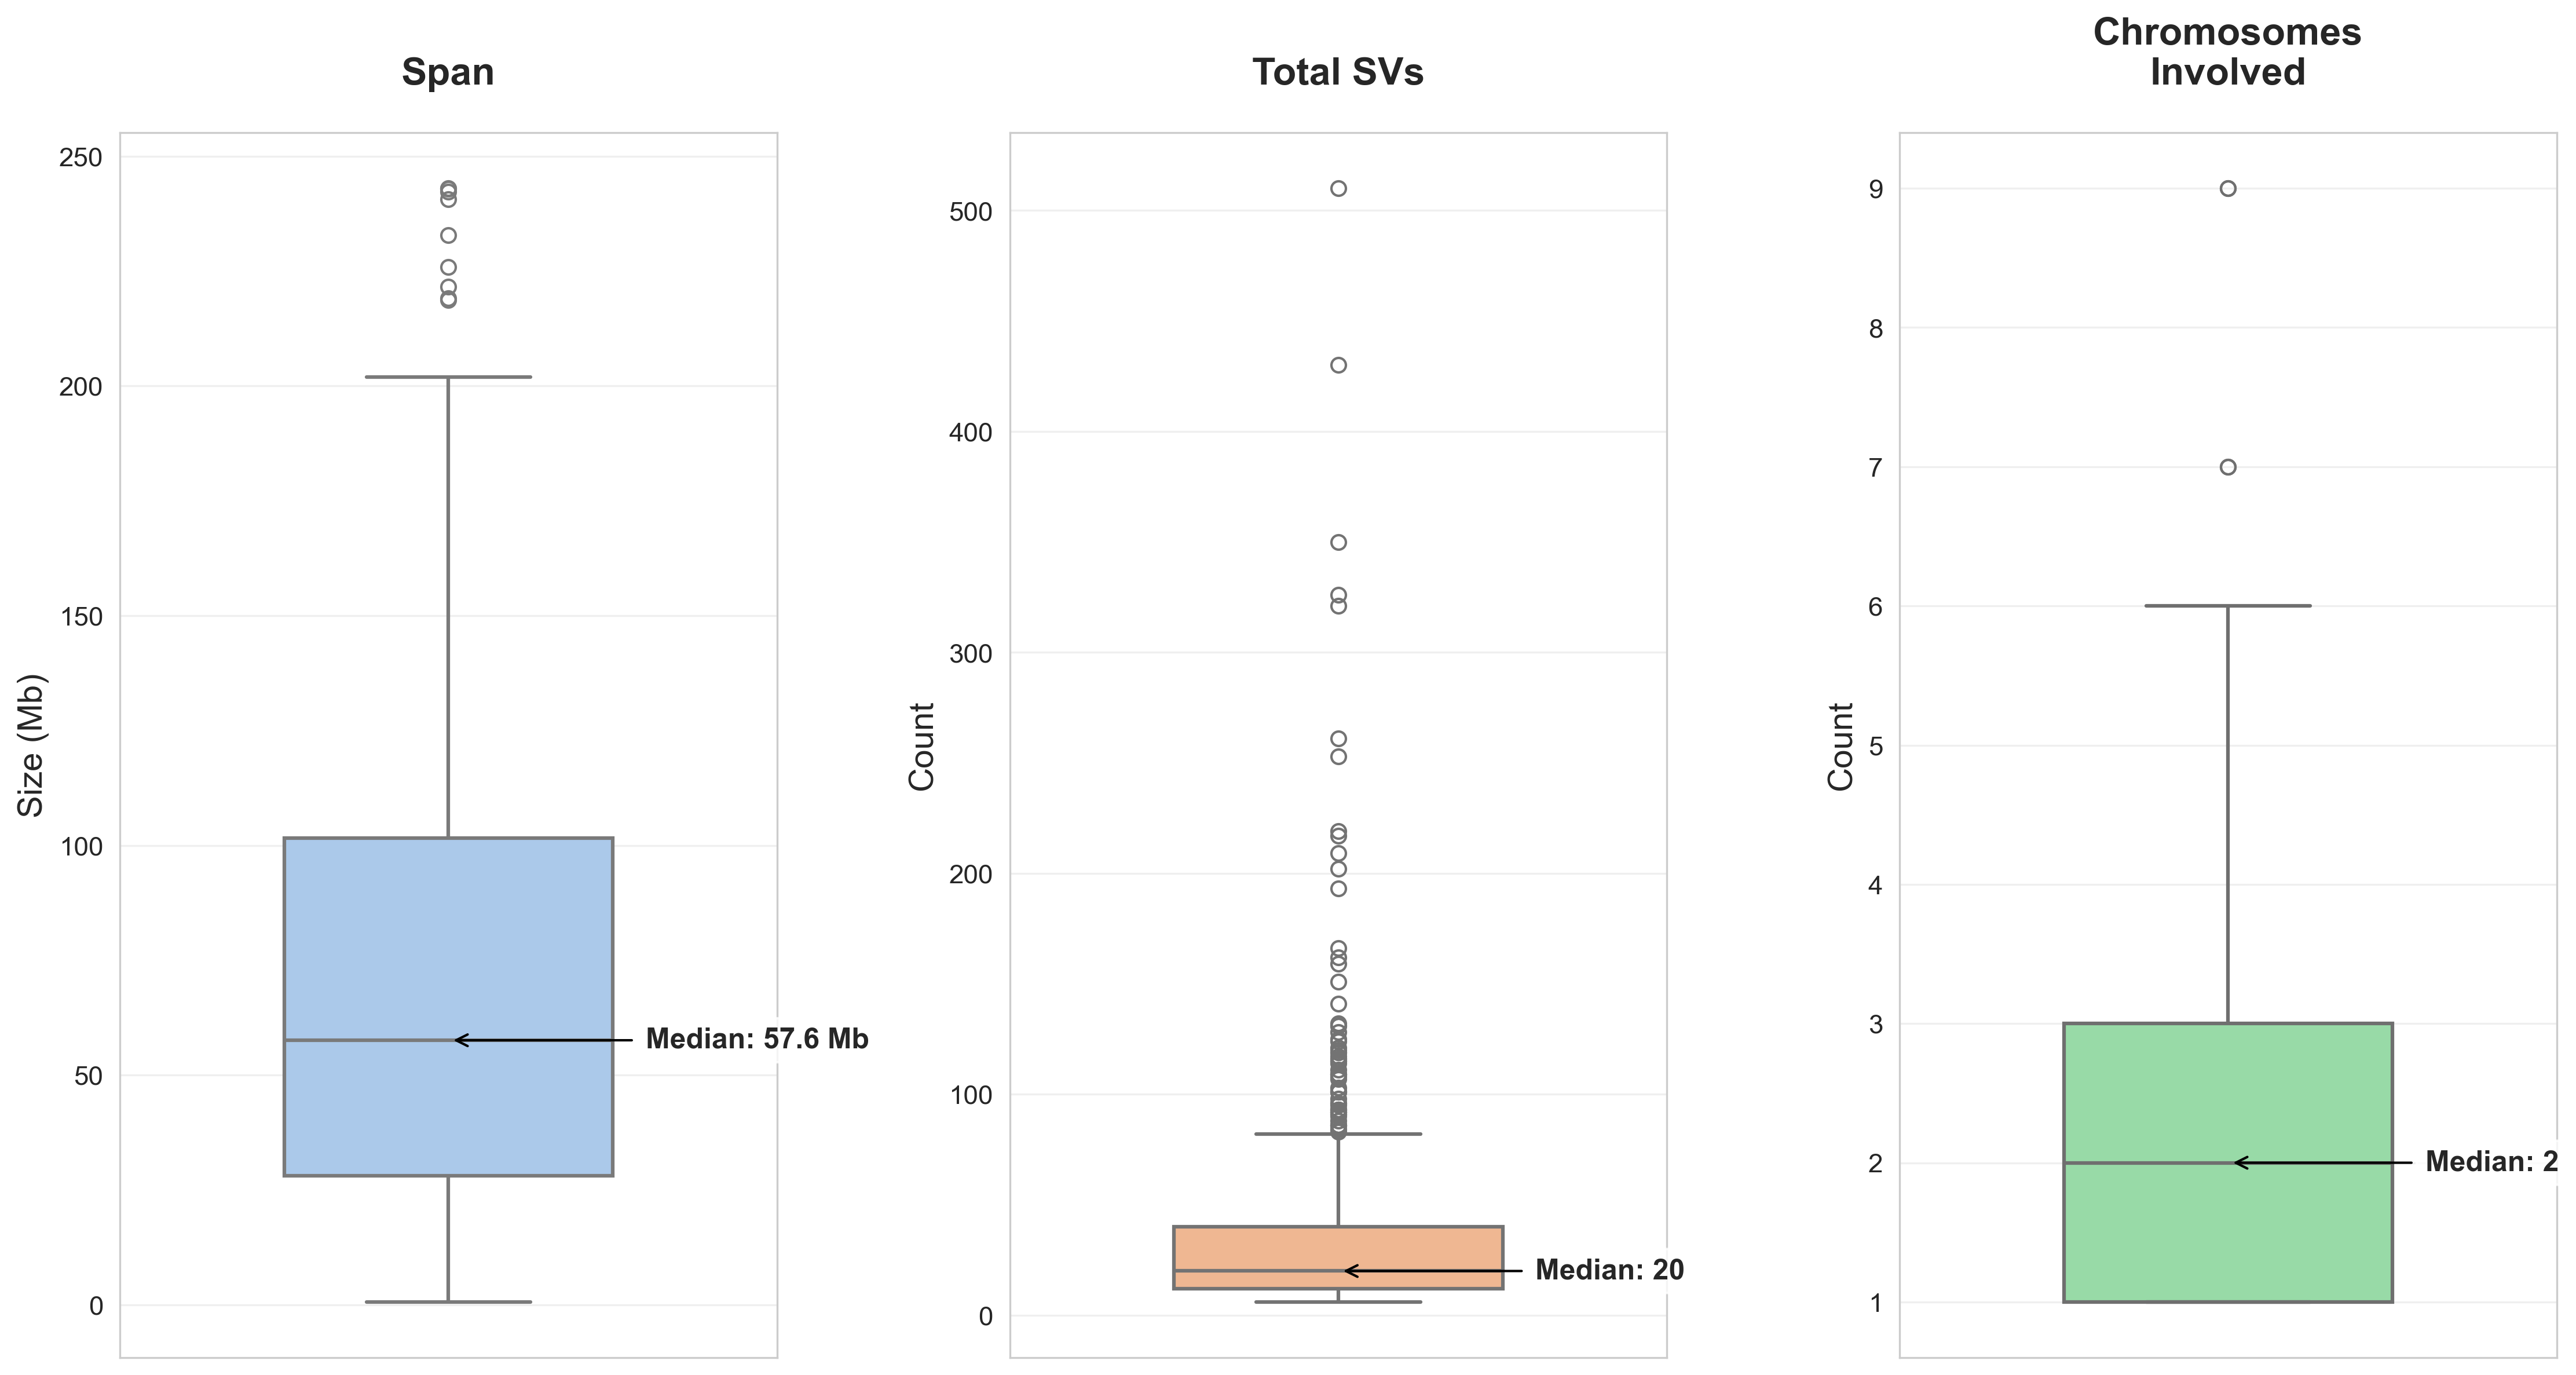

In [6]:
# IMPORTANT: this is for all samples (including multiple tumors)
'''
# Filter for high confidence events only
high_confidence_chromothripsis = chromothripsis_classified[
    chromothripsis_classified['confidence_level'] == 'High confidence'
].copy()
'''
# if we want to include low confidence chromothripsis events:
high_confidence_chromothripsis = chromothripsis_classified.copy() 

# Parse linked chromosomes and count chromosomes per event
def parse_inter_chroms(inter_chroms_str):
    if pd.isna(inter_chroms_str) or inter_chroms_str.strip() == "":
        return []
    return [entry.split(':')[0].strip() for entry in inter_chroms_str.split(';') 
            if ':' in entry and entry.split(':')[0].strip()]

high_confidence_chromothripsis['linked_chroms'] = high_confidence_chromothripsis['inter_other_chroms_coords_all'].apply(parse_inter_chroms)
high_confidence_chromothripsis['num_linked_chroms'] = high_confidence_chromothripsis['linked_chroms'].apply(len)
high_confidence_chromothripsis['total_chroms_involved'] = high_confidence_chromothripsis['num_linked_chroms'] + 1  # +1 for primary chromosome

# Chromosomes involved per event
print(f"\nNumber of events involving multiple chromosomes: {(high_confidence_chromothripsis['total_chroms_involved'] > 1).sum()}/{len(high_confidence_chromothripsis)}")

# Set high DPI for better resolution
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Set seaborn style with pastel colors
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Calculate span of chromothripsis events (in Mb)
high_confidence_chromothripsis['span_bp'] = high_confidence_chromothripsis['end'] - high_confidence_chromothripsis['start']
high_confidence_chromothripsis['span_mb'] = high_confidence_chromothripsis['span_bp'] / 1_000_000

# Prepare data for boxplots
metrics_data = {
    'Span': high_confidence_chromothripsis['span_mb'],
    'Total SVs': high_confidence_chromothripsis['clusterSize_including_TRA'],
    'Chromosomes\nInvolved': high_confidence_chromothripsis['total_chroms_involved']
}

# Create figure with subplots (1 row, 3 columns) - adjusted size for better proportions
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Get pastel colors from seaborn
pastel_colors = sns.color_palette("pastel", 3)

# Create individual boxplots with seaborn styling
for i, (metric_name, data) in enumerate(metrics_data.items()):
    ax = axes[i]
    
    # Create seaborn boxplot
    sns.boxplot(y=data.dropna(), 
               color=pastel_colors[i],
               linewidth=1.5,
               width=0.5,
               ax=ax)
    
    # Customize the plot
    ax.set_title(metric_name, fontsize=16, fontweight='bold', pad=20)
    
    # Set appropriate y-label based on metric
    if 'Span' in metric_name:
        ax.set_ylabel('Size (Mb)', fontsize=14)
    elif 'SVs' in metric_name:
        ax.set_ylabel('Count', fontsize=14)
    else:
        ax.set_ylabel('Count', fontsize=14)
    
    ax.set_xlabel('')
    
    # Calculate median for annotation
    median_value = data.median()
    
    # Format median annotation based on metric type
    if 'Span' in metric_name:
        median_text = f'Median: {median_value:.1f} Mb'
    else:
        median_text = f'Median: {median_value:.0f}'
    
    # Add median annotation
    ax.annotate(median_text, 
                xy=(0, median_value), 
                xytext=(0.3, median_value),
                fontsize=12,
                fontweight='bold',
                ha='left',
                va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='black', lw=1))
    
    # Improve styling
    ax.grid(True, alpha=0.3, axis='y', linewidth=0.8)
    ax.tick_params(axis='y', labelsize=11)
    
    # Remove x-axis ticks since it's just one group
    ax.set_xticks([])
    
    # Print stats for each metric
    print(f"\n{metric_name.replace(chr(10), ' ')} Statistics:")
    if 'Span' in metric_name:
        print(f"  Median: {data.median():.1f} Mb")
        print(f"  Mean: {data.mean():.1f} Mb")
        print(f"  Std: {data.std():.1f} Mb")
        print(f"  Min: {data.min():.1f} Mb")
        print(f"  Max: {data.max():.1f} Mb")
    else:
        print(f"  Median: {data.median():.1f}")
        print(f"  Mean: {data.mean():.1f}")
        print(f"  Std: {data.std():.1f}")
        print(f"  Min: {data.min():.1f}")
        print(f"  Max: {data.max():.1f}")

plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.savefig('../results/plots/chromothripsis_heterogeneity_boxplots.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# add COSMIC gene annotations to ShatterSeek results
def add_cosmic_annotations(results_df, cosmic_file='../../SRB_analysis/data/hg38_ref_files/Cosmic_CancerGeneCensus_v102_GRCh38.tsv'):

    cosmic_df = pd.read_csv(cosmic_file, sep='\t')
    
    # clean chromosome column
    cosmic_df['CHROMOSOME'] = cosmic_df['CHROMOSOME'].astype(str)
    cosmic_df['CHROMOSOME'] = cosmic_df['CHROMOSOME'].replace({'X': '23', 'Y': '24'})
    
    # Initialize new columns
    results_df = results_df.copy()
    results_df['cosmic_genes'] = ''
    results_df['cosmic_gene_count'] = 0
    results_df['has_tier1_gene'] = False
    
    # Annotate each event
    for idx, row in results_df.iterrows():
        
        chrom = str(row['chrom'])
        start = row['start'] 
        end = row['end']
        
        # Find overlapping COSMIC genes
        chrom_genes = cosmic_df[cosmic_df['CHROMOSOME'] == chrom]
        overlapping = chrom_genes[
            (chrom_genes['GENOME_START'] <= end) & 
            (chrom_genes['GENOME_STOP'] >= start)
        ]
        
        if len(overlapping) > 0:
            gene_symbols = overlapping['GENE_SYMBOL'].tolist()
            tiers = overlapping['TIER'].tolist()
            
            results_df.at[idx, 'cosmic_genes'] = ';'.join(gene_symbols)
            results_df.at[idx, 'cosmic_gene_count'] = len(gene_symbols)
            results_df.at[idx, 'has_tier1_gene'] = 1 in tiers
    
    genes_found = (results_df['cosmic_gene_count'] > 0).sum()
    print(f"{genes_found} events have COSMIC gene overlaps out of {len(results_df)}")
    
    return results_df

annotated_chromothripsis = add_cosmic_annotations(chromothripsis_classified)

# Show summary
print(f"\nSummary:")
print(f"Events with COSMIC genes: {(annotated_chromothripsis['cosmic_gene_count'] > 0).sum()}")
print(f"Events with Tier 1 genes: {annotated_chromothripsis['has_tier1_gene'].sum()}")
print(f"Total gene overlaps: {annotated_chromothripsis['cosmic_gene_count'].sum()}")
annotated_chromothripsis.to_csv('../results/chromothripsis_events.csv', index=False)

622 events have COSMIC gene overlaps out of 634

Summary:
Events with COSMIC genes: 622
Events with Tier 1 genes: 614
Total gene overlaps: 11063
